<a href="https://colab.research.google.com/github/srilekab2024laiml-lang/Srileka-CodeBooster-2026/blob/main/Day10/Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
df = pd.read_csv("student_performance.csv")

In [4]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [7]:
import pandas as pd
df = pd.read_csv("student_performance.csv")
print("The dataset is completly added!")

The dataset is completly added!


In [10]:
import sqlite3

conn = sqlite3.connect('student_database.db')
df.to_sql("student_events", conn, if_exists="replace", index=False)

print("Data imported successfully!")

Data imported successfully!


In [12]:
query = """
SELECT name, department
FROM student_events
WHERE gender = 'Female'
"""
result = pd.read_sql(query, conn)
print(result)

              name        department
0      Priya Patel  Computer Science
1      Sneha Reddy        Mechanical
2      Meera Joshi       Electronics
3      Divya Singh  Computer Science
4       Ananya Das  Computer Science
5      Pooja Gupta             Civil
6    Kavya Nambiar        Mechanical
7     Ritu Agarwal       Electronics
8   Swati Kulkarni  Computer Science
9     Nisha Kapoor  Computer Science
10     Tanvi Mehta  Computer Science
11   Preeti Saxena        Mechanical
12      Rekha Nair       Electronics
13   Sunita Pillai             Civil
14  Akanksha Yadav  Computer Science


In [14]:
query = "SELECT * FROM student_events LIMIT 5"
result = pd.read_sql(query, conn)
print(result)

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [20]:
query = """
SELECT name, math_score
FROM student_events;
"""
result_df = pd.read_sql(query, conn)
print(result_df)

              name  math_score
0     Aarav Sharma          85
1      Priya Patel          76
2      Rohit Verma          65
3      Sneha Reddy          70
4       Arjun Nair          92
5      Meera Joshi          58
6      Kiran Kumar          73
7      Divya Singh          88
8     Rahul Mishra          62
9       Ananya Das          95
10     Vikram Iyer          80
11     Pooja Gupta          67
12      Suresh Rao          83
13   Kavya Nambiar          74
14     Ajay Tiwari          71
15    Ritu Agarwal          87
16    Manoj Pandey          56
17  Swati Kulkarni          90
18  Deepak Chauhan          68
19    Nisha Kapoor          79
20   Harish Pillai          64
21     Tanvi Mehta          93
22    Sanjay Dubey          61
23   Preeti Saxena          77
24       Amit Bose          86
25      Rekha Nair          72
26   Gaurav Shukla          84
27   Sunita Pillai          60
28      Nitin Jain          75
29  Akanksha Yadav          91


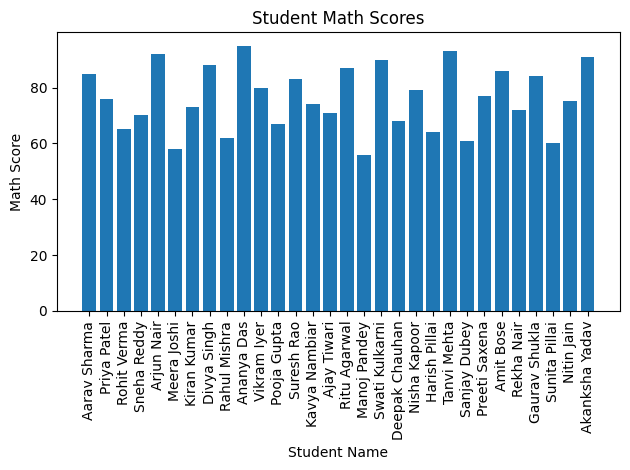

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect database
conn = sqlite3.connect("student_database.db") # Corrected database name

# Query
query = """
SELECT name, math_score
FROM student_events;
"""

# Load data
df = pd.read_sql_query(query, conn)

# Bar Chart
plt.bar(df['name'], df['math_score'])
plt.xlabel("Student Name")
plt.ylabel("Math Score")
plt.title("Student Math Scores")
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [39]:
drop_query = """
DROP TABLE IF EXISTS cleaned_students;
"""

create_query = """
CREATE TABLE cleaned_students AS
SELECT
    student_id,
    name AS student_name,
    math_score,
    CASE
        WHEN math_score >= 90 THEN 'Excellent'
        WHEN math_score >= 75 THEN 'Good'
        WHEN math_score >= 50 THEN 'Average'
        ELSE 'Needs Improvement'
    END AS performance
FROM student_events
WHERE math_score IS NOT NULL;
"""

conn.execute(drop_query)
conn.execute(create_query)
conn.commit()

print("Table 'cleaned_students' created with performance categories.")

Table 'cleaned_students' created with performance categories.


In [48]:
import requests

API_KEY = "33499632c1a18060c1259394749d19ef"

city = "Chennai"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()


    print("City:", data["name"])
    print("Temperature:", round(data["main"]["temp"] - 273.15, 2), "°C") # Convert Kelvin to Celsius
    print("Humidity:", data["main"]["humidity"], "%")
    print("Weather:", data["weather"][0]["description"])
    print("Wind Speed:", data["wind"]["speed"], "m/s")
else:
    print(f"Error fetching data: {response.status_code} - {response.text}")


City: Chennai
Temperature: 36.09 °C
Humidity: 50 %
Weather: overcast clouds
Wind Speed: 2.24 m/s


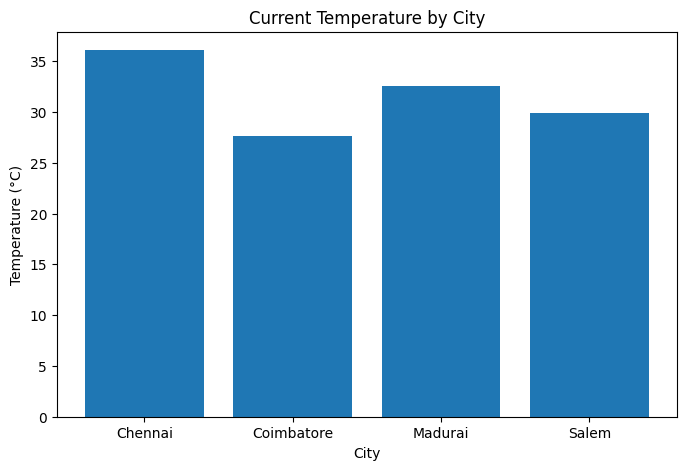

In [50]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "33499632c1a18060c1259394749d19ef"

cities = ["Chennai", "Coimbatore", "Madurai", "Salem"]
temperatures = []

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()

    temperatures.append(data["main"]["temp"])

df = pd.DataFrame({
    "City": cities,
    "Temperature": temperatures
})

plt.figure(figsize=(8,5))
plt.bar(df["City"], df["Temperature"])
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.title("Current Temperature by City")
plt.show()

In [7]:


from pyspark.sql import SparkSession
from pyspark.sql.functions import when

spark = SparkSession.builder \
    .appName("StudentAnalysis") \
    .getOrCreate()

data = [
    (1, "Ravi", 95),
    (2, "Priya", 82),
    (3, "Arun", 68),
    (4, "Divya", 55),
    (5, "Kumar", 40)
]

columns = ["student_id", "student_name", "math_score"]


df = spark.createDataFrame(data, columns)


df_transformed = df.withColumn(
    "performance",
    when(df.math_score >= 90, "Excellent")
    .when(df.math_score >= 75, "Good")
    .when(df.math_score >= 50, "Average")
    .otherwise("Needs Improvement")
)

df_transformed.show()

+----------+------------+----------+-----------------+
|student_id|student_name|math_score|      performance|
+----------+------------+----------+-----------------+
|         1|        Ravi|        95|        Excellent|
|         2|       Priya|        82|             Good|
|         3|        Arun|        68|          Average|
|         4|       Divya|        55|          Average|
|         5|       Kumar|        40|Needs Improvement|
+----------+------------+----------+-----------------+



In [13]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

spark = SparkSession.builder.appName("StudentPrediction").getOrCreate()


data = [
    (1, 70, 75),
    (2, 80, 85),
    (3, 90, 95),
    (4, 60, 65),
    (5, 85, 88)
]

columns = ["student_id", "math_score", "final_score"]

df = spark.createDataFrame(data, columns)


assembler = VectorAssembler(
    inputCols=["math_score"],
    outputCol="features"
)

df_features = assembler.transform(df)

lr = LinearRegression(
    featuresCol="features",
    labelCol="final_score"
)

model = lr.fit(df_features)


new_data = spark.createDataFrame(
    [(95,)],
    ["math_score"]
)

new_features = assembler.transform(new_data)
prediction = model.transform(new_features)

predicted_score = prediction.collect()[0]["prediction"]

if predicted_score >= 90:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance is Excellent."
elif predicted_score >= 75:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance is Good."
else:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance needs improvement."

print(message)

The student is predicted to score 99.10. Performance is Excellent.
